# E04 - Source-Conditioned Performance d(A,B|S) - speed and resolution

Batch E04 tests five pre-registered levers that aim to make the shipped source-conditioned distance
faster and higher-resolution without losing the correctness E02/E03 secured, on the IBM AI-adoption
executive-summary fixtures. Two levers target resolution (the dynamic-range axis E01 left as the one
with room, never applied to the conditioned distance), two target the reranker cost (the structural
60% the E03 bi-encoder levers could not remove), one composite capstone stacks the winners. Each
hypothesis runs its pre-registered kill-gate probe first, then builds, then prints a computed
PASS/FAIL against its acceptance bar.

## Approach

1. **Load the chain and the E03 operating point** - mmBERT, `bge-reranker-v2-m3`, `mdeberta-mnli-xnli`
   on GPU fp16; rebuild the shipped baseline (selection `D_sel`, the E03-H2 relevance-gated grounding
   `D_grd`, the symmetric SMD) as the reference every lever must hold against
2. **H1 anisotropy on the conditioned axes** - all-but-the-top over the pooled {A,B,S} statements
   before the coverage profile; sweep `k`, measure `D_sel` dynamic range and violations
3. **H2 coverage-temperature sharpening** - sweep the coverage softmax temperature, measure `D_sel`
   contrast, dynamic range and violations
4. **H3 distilled cross-encoder replacement** - replace `v2-m3` with the smaller `bge-reranker-base`,
   measure `D_grd` ranking fidelity (Spearman), recall and latency
5. **H4 small cross-encoder cascade** - a tiny MiniLM shortlists the top-m source, `v2-m3` reranks
   only those; measure fidelity, recall and the `v2-m3` call cut
6. **H5 composite** - stack the landed resolution and speed winners, re-check every KPI head-to-head
   against the E03 operating point and the symmetric SMD

## Outputs

- A PASS/FAIL verdict per hypothesis against its pre-registered acceptance bar
- `reports/E04-source-conditioned-performance-metrics.json` - the measured numbers for the doc update
- One figure - the H1/H2 resolution sweeps and the H5 composite plane
- Execution log `logs/E04-source-conditioned-performance.log`


## GPU selection

Select the RTX 5000 Ada (sm_89, 32 GB) before importing torch; the whole grounding chain runs torch fp16 on GPU.

In [1]:
import os

USE_GPU = True                                    # GPU torch fp16 chain
GPU_INDEX = "2"                                   # nvidia-smi index (RTX 5000 Ada, sm_89, 32 GB)

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"    # align torch index with nvidia-smi
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_INDEX if USE_GPU else ""
os.environ["HF_HUB_OFFLINE"] = "1"                # all weights cached; the chain never fetches
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="torch.jit._script")
print(f"backend: {'GPU torch fp16' if USE_GPU else 'CPU OpenVINO INT8'}; CUDA_VISIBLE_DEVICES={os.environ['CUDA_VISIBLE_DEVICES']!r}")

backend: GPU torch fp16; CUDA_VISIBLE_DEVICES='2'


## Imports

Numerics, the grounding cross-encoders, and the shipped library (selection axis + symmetric baseline, public API).

In [2]:
%load_ext autoreload
%autoreload 2

import json
import time
import contextlib
import io
from pathlib import Path

import numpy as np
import scipy.special as sp
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers.utils import logging as hf_logging
from huggingface_hub import snapshot_download

from docdistance import DocDistance
from docdistance.distance import coverage_profile, selection_divergence, compute_distance, all_but_the_top
import docdistance

console = Console()
sns.set_theme(style="whitegrid")
hf_logging.disable_progress_bar()
DEVICE = "cuda" if (USE_GPU and torch.cuda.is_available()) else "cpu"
print("docdistance", docdistance.__version__, "| torch", torch.__version__, "| device", DEVICE,
      "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU")

docdistance 1.0.15 | torch 2.12.1+cu130 | device cuda | NVIDIA RTX 5000 Ada Generation


## Reproducibility

Fixed seed; deterministic apart from natural fp16 reduction-order variance on GPU.

In [3]:
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
print("seed", SEED)

seed 0


## Configuration

Fixtures, the grounding models per backend, the two small rerankers under test (H3 replacement, H4 cascade), and the pre-registered sweep ranges and acceptance bars.

In [4]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
SUMMARY_DIR = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/summaries"
SOURCE_FILE = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/source/source-article.md"

DOCS = [
    ("exec-summary-gold-opus-4-5.md",     "gold",   "gold"),   # reference anchor
    ("exec-summary-gold-2-opus-4-5.md",   "gold-2", "gold"),
    ("exec-summary-1-opus-4-5.md",        "v1",     "gold"),
    ("exec-summary-2-opus-4-5.md",        "v2",     "gold"),
    ("exec-summary-opus-4-5.md",          "opus",   "gold"),
    ("exec-summary-sonnet-4-6.md",        "sonnet", "gold"),
    ("exec-summary-haiku-4-5.md",         "haiku",  "gold"),
    ("exec-summary-adv1-a-sonnet-4-6.md", "adv1-a", "adv1"),
    ("exec-summary-adv1-b-sonnet-4-6.md", "adv1-b", "adv1"),
    ("exec-summary-adv2-a-haiku-4-5.md",  "adv2-a", "adv2"),
    ("exec-summary-adv2-b-haiku-4-5.md",  "adv2-b", "adv2"),
]
REFERENCE = "gold"
TIER = {label: tier for (_, label, tier) in DOCS}
TIER_COLOR = {"gold": "#2ca02c", "adv1": "#ff7f0e", "adv2": "#d62728"}
TIER_NAME = {"gold": "gold (faithful)", "adv1": "Set 1 (info-loss)", "adv2": "Set 2 (info-noise)"}
TIERS = ["gold", "adv1", "adv2"]

RERANKER = {"cpu": "stellars/bge-reranker-v2-m3-openvino-int8",        "gpu": "BAAI/bge-reranker-v2-m3"}
NLI =      {"cpu": "stellars/mdeberta-v3-base-mnli-xnli-openvino-int8", "gpu": "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"}
SMALL = {"base": "BAAI/bge-reranker-base",                  # H3 distilled replacement (same family, ~2x smaller)
         "mini": "cross-encoder/ms-marco-MiniLM-L-6-v2"}    # H4 cascade pre-filter (tiny, ~25x cheaper)
ENC_BACKEND = "torch" if DEVICE == "cuda" else "openvino"
MAX_TOKENS, PAIR_BATCH, TOP_K = 256, 256, 3
ALPHA = 0.75                                       # E03-H5 blend operating point

# pre-registered sweeps and acceptance bars
K_ANISO = [1, 2, 3]                                # H1 all-but-the-top k
TAU_SWEEP = [0.2, 0.1, 0.05, 0.02, 0.01]           # H2 coverage temperature
CASCADE_M = 15                                     # H4 shortlist size
DR_BAR = 1.5                                       # H1 D_sel DR ratio bar
CONTRAST_BAR = 1.20                                # H2 contrast uplift bar (+20%)
ANISO_GATE = 0.6                                   # H1 kill-gate: pooled cosine anisotropy
SPEARMAN_BAR = 0.95                                # H3/H4 D_grd ranking fidelity
RECALL3_BAR = 0.90                                 # H3 kill-gate: small top-3 recalls v2m3 top-3
RECALLM_BAR = 0.95                                 # H4 kill-gate: mini top-m recalls v2m3 top-3
H3_SPEED_BAR, H4_SPEED_BAR = 3.0, 2.0              # reranker latency cut bars

t = Table(title="configuration", title_style="bold cyan", show_header=False, box=None, padding=(0, 2))
t.add_column(style="bold cyan"); t.add_column()
t.add_row("Fixtures", f"{len(DOCS)} summaries + 1 source, 3 tiers")
t.add_row("Anchor", f"{REFERENCE} (Opus 3-sweep)")
t.add_row("Device", f"{DEVICE} ({torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'CPU'})")
t.add_row("mmBERT encoder", f"{ENC_BACKEND} ({'fp16' if DEVICE=='cuda' else 'INT8'})")
t.add_row("Reranker (v2-m3)", RERANKER["gpu" if DEVICE == "cuda" else "cpu"])
t.add_row("NLI", NLI["gpu" if DEVICE == "cuda" else "cpu"])
t.add_row("H3 distilled reranker", SMALL["base"])
t.add_row("H4 cascade pre-filter", SMALL["mini"])
t.add_row("H1 k sweep / DR bar", f"{K_ANISO} / >= {DR_BAR}x")
t.add_row("H2 tau sweep / contrast bar", f"{TAU_SWEEP} / >= {CONTRAST_BAR}x")
t.add_row("H4 cascade m", str(CASCADE_M))
console.print(t)

                              configuration                               
  Fixtures                       11 summaries + 1 source, 3 tiers         
  Anchor                         gold (Opus 3-sweep)                      
  Device                         cuda (NVIDIA RTX 5000 Ada Generation)    
  mmBERT encoder                 torch (fp16)                             
  Reranker (v2-m3)               BAAI/bge-reranker-v2-m3                  
  NLI                            MoritzLaurer/mDeBERTa-v3-base-mnli-xnli  
  H3 distilled reranker          BAAI/bge-reranker-base                   
  H4 cascade pre-filter          cross-encoder/ms-marco-MiniLM-L-6-v2     
  H1 k sweep / DR bar            [1, 2, 3] / >= 1.5x                      
  H2 tau sweep / contrast bar    [0.2, 0.1, 0.05, 0.02, 0.01] / >= 1.2x   
  H4 cascade m                   15

## Grounding cross-encoders

Load the v2-m3 reranker, the NLI entailer, and the two small rerankers under test. All torch fp16 on GPU.

In [5]:
class OVSeqModel:
    # OpenVINO INT8 sequence-classifier (CPU) - tokenize text pairs, return raw logits
    def __init__(self, repo):
        import openvino as ov
        d = Path(snapshot_download(repo)); core = ov.Core()
        m = core.read_model(str(d / "openvino_model.xml"))
        self.innames = [i.get_any_name() for i in m.inputs]
        self.cm = core.compile_model(m, "CPU", {"PERFORMANCE_HINT": "THROUGHPUT"})
        self.tok = AutoTokenizer.from_pretrained(str(d))
        self.id2label = json.load(open(d / "config.json")).get("id2label", {})
    def logits(self, a, b, max_len=MAX_TOKENS, batch=PAIR_BATCH):
        out = []
        for i in range(0, len(a), batch):
            enc = self.tok(a[i:i+batch], b[i:i+batch], padding=True, truncation=True,
                           max_length=max_len, return_tensors="np")
            out.append(self.cm({self.innames[0]: enc["input_ids"], self.innames[1]: enc["attention_mask"]})[self.cm.output(0)])
        return np.concatenate(out, 0)


class TorchSeqModel:
    # torch fp16 sequence-classifier (GPU) - the original FP weights
    def __init__(self, repo):
        self.tok = AutoTokenizer.from_pretrained(repo)
        dtype = torch.float16 if DEVICE == "cuda" else torch.float32
        self.m = AutoModelForSequenceClassification.from_pretrained(repo).to(DEVICE).to(dtype).eval()
        self.id2label = {int(k): v for k, v in self.m.config.id2label.items()}
    @torch.no_grad()
    def logits(self, a, b, max_len=MAX_TOKENS, batch=PAIR_BATCH):
        out = []
        for i in range(0, len(a), batch):
            enc = self.tok(a[i:i+batch], b[i:i+batch], padding=True, truncation=True,
                           max_length=max_len, return_tensors="pt").to(DEVICE)
            out.append(self.m(**enc).logits.float().cpu().numpy())
        return np.concatenate(out, 0)


def load_grounders(device):
    key = "gpu" if device == "cuda" else "cpu"
    Model = TorchSeqModel if device == "cuda" else OVSeqModel
    with contextlib.redirect_stderr(io.StringIO()):
        return Model(RERANKER[key]), Model(NLI[key])


with contextlib.redirect_stderr(io.StringIO()):
    dd = DocDistance(backend=ENC_BACKEND, device=DEVICE if DEVICE == "cuda" else None)
    reranker, nli = load_grounders(DEVICE)
    rr_base = TorchSeqModel(SMALL["base"])          # H3 distilled replacement
    rr_mini = TorchSeqModel(SMALL["mini"])          # H4 cascade pre-filter
ENTAIL = [int(k) for k, v in nli.id2label.items() if str(v).lower().startswith("entail")][0]
print("device", DEVICE, "| nli entail idx", ENTAIL,
      "| small rerankers:", SMALL["base"].split("/")[-1], "+", SMALL["mini"].split("/")[-1])

device cuda | nli entail idx 0 | small rerankers: bge-reranker-base + ms-marco-MiniLM-L-6-v2


## Data loading and grounding signals

Segment and embed every summary and the source, then score each summary against all 70 source statements with all three rerankers once. Stores the full v2-m3 / base / mini grids per document for the fidelity and recall measures below.

In [6]:
def body(path):
    return "\n".join(l for l in Path(path).read_text().splitlines() if not l.startswith("# ")).strip()

S_texts = dd.segmenter.split(body(SOURCE_FILE))
S_emb = dd.encoder.encode(S_texts)


def grid(model, x_texts):
    xs = [x for x in x_texts for _ in S_texts]; ss = [s for _ in x_texts for s in S_texts]
    return sp.expit(model.logits(xs, ss)).reshape(len(x_texts), len(S_texts))


def joint_ent(x_texts, rel, k=TOP_K):
    prem = [" ".join(S_texts[j] for j in np.argsort(rel[i])[::-1][:k]) for i in range(len(x_texts))]
    P = sp.softmax(nli.logits(prem, x_texts), axis=1)
    return P[:, ENTAIL]


docs = {}
t0 = time.perf_counter()
for n, (fname, label, tier) in enumerate(DOCS, 1):
    txts = dd.segmenter.split(body(SUMMARY_DIR / fname))
    emb = dd.encoder.encode(txts)
    Rbig = grid(reranker, txts); Rbase = grid(rr_base, txts); Rmini = grid(rr_mini, txts)
    ent = joint_ent(txts, Rbig)
    docs[label] = dict(texts=txts, emb=emb, tier=tier, cov=coverage_profile(emb, S_emb),
                       Rbig=Rbig, Rbase=Rbase, Rmini=Rmini, maxR=Rbig.max(1), ent=ent,
                       sig_gate=np.array([float(np.mean((1.0 - ent) * (1.0 - Rbig.max(1)))), 0.0]))
    print(f"  [{n:2d}/{len(DOCS)}] {label:8s} {len(txts):2d} stmts  ({time.perf_counter()-t0:5.1f}s)", flush=True)
print(f"signals for {len(docs)} documents in {time.perf_counter()-t0:.1f}s on {DEVICE}")

  [ 1/11] gold     12 stmts  (  2.3s)


  [ 2/11] gold-2   12 stmts  (  4.4s)


  [ 3/11] v1       12 stmts  (  6.5s)


  [ 4/11] v2       11 stmts  (  8.5s)


  [ 5/11] opus     13 stmts  ( 10.6s)


...

  [ 8/11] adv1-a   12 stmts  ( 17.0s)


  [ 9/11] adv1-b    8 stmts  ( 18.6s)


  [10/11] adv2-a   13 stmts  ( 21.9s)


  [11/11] adv2-b    9 stmts  ( 24.8s)


signals for 11 documents in 24.8s on cuda


## Baseline and metric helpers

The E03 operating point - shipped `D_sel`, the E03-H2 relevance-gated `D_grd`, the symmetric SMD - plus the KPI helpers each lever is scored on (dynamic range, contrast, violations, gold intrusions, severity).

In [7]:
ANCHOR = REFERENCE
labels = list(docs)
gold_labels = [l for l in labels if TIER[l] == "gold"]
adv_labels = [l for l in labels if TIER[l] != "gold"]
set1 = [l for l in labels if TIER[l] == "adv1"]; set2 = [l for l in labels if TIER[l] == "adv2"]
NONANCHOR = [l for l in labels if l != ANCHOR]


def tier_means(score):
    return {tn: float(np.mean([score[l] for l in labels if TIER[l] == tn])) for tn in TIERS}

def violations(score):
    return sum(1 for g in gold_labels for a in adv_labels if score[g] >= score[a]), len(gold_labels) * len(adv_labels)

def gold_intrusions(score):
    floor = min(score[l] for l in set2)
    return sum(1 for l in gold_labels if score[l] >= floor)

def severity_order(score):
    s1 = [score[l] for l in set1]; s2 = [score[l] for l in set2]
    if min(s2) > max(s1): return "Set2>Set1"
    if min(s1) > max(s2): return "Set1>Set2"
    return "interleaved"

def DR(score):                       # dynamic range: std of the non-anchor -> ref distances
    return float(np.std([score[l] for l in NONANCHOR]))

def contrast(score):                 # scale-free gold -> adversarial spread on the axis
    g = np.mean([score[l] for l in NONANCHOR if TIER[l] == "gold"])
    a = np.mean([score[l] for l in labels if TIER[l] != "gold"])
    return float(a / g) if g > 0 else float("inf")

def dgrd_gated(ent_map, maxR_map):   # E03-H2 gated grounding residual -> signature distance from anchor
    sig = {l: np.array([float(np.mean((1.0 - ent_map[l]) * (1.0 - maxR_map[l]))), 0.0]) for l in labels}
    a = sig[ANCHOR]
    return {l: float(np.linalg.norm(sig[l] - a)) for l in labels}


d_sel = {l: selection_divergence(docs[ANCHOR]["cov"], docs[l]["cov"], S_emb) for l in labels}
d_grd = {l: float(np.linalg.norm(docs[l]["sig_gate"] - docs[ANCHOR]["sig_gate"])) for l in labels}
d_sym = {l: compute_distance(docs[ANCHOR]["emb"], docs[l]["emb"]).smd for l in labels}
DR0, V0, GI0, CON0 = DR(d_sel), violations(d_sel)[0], gold_intrusions(d_grd), contrast(d_sel)

bt = Table(title="E03 operating point (the baseline E04 must hold)", title_style="bold cyan", box=None, padding=(0, 2))
bt.add_column("axis", style="bold"); [bt.add_column(c, justify="right") for c in ["gold", "Set 1", "Set 2", "KPI"]]
for name, sc, kpi in [("D_sel (selection)", d_sel, f"DR {DR0:.4f}, V {V0}, contrast {CON0:.2f}x"),
                      ("D_grd gated (H2)", d_grd, f"gold intrusions {GI0}"),
                      ("SMD (symmetric)", d_sym, f"severity {severity_order(d_sym)}")]:
    m = tier_means(sc)
    bt.add_row(name, f"{m['gold']:.4f}", f"{m['adv1']:.4f}", f"{m['adv2']:.4f}", kpi)
console.print(bt)
print(f"baseline: D_sel DR {DR0:.4f}, {V0} violations, contrast {CON0:.3f}x; D_grd {GI0} gold intrusions; symmetric {severity_order(d_sym)}")

                  E03 operating point (the baseline E04 must hold)                   
  axis                   gold     Set 1     Set 2                               KPI  
  D_sel (selection)    0.0236    0.0569    0.0704    DR 0.0193, V 0, contrast 2.31x  
  D_grd gated (H2)     0.0704    0.1194    0.2115                 gold intrusions 0  
  SMD (symmetric)      0.2848    0.4442    0.4015                severity Set1>Set2

baseline: D_sel DR 0.0193, 0 violations, contrast 2.308x; D_grd 0 gold intrusions; symmetric Set1>Set2


## E04-H1 - anisotropy removal on the conditioned axes

All-but-the-top over the pooled {A,B,S} statements before the coverage profile, sweeping `k`. **Kill-gate** - the pooled statement cosines must be anisotropic (mean off-diagonal cosine >= 0.6). **Bar** - `D_sel` DR >= 1.5x baseline AND 0 selection violations AND `D_grd` intrusions unchanged (anisotropy is text-blind, so `D_grd` is unchanged by construction).

In [8]:
pool = np.concatenate([docs[l]["emb"] for l in labels] + [S_emb], 0)
G = pool @ pool.T
aniso = float(G[~np.eye(len(G), dtype=bool)].mean())
kill_h1 = aniso >= ANISO_GATE
print(f"H1 kill-gate: pooled mean off-diagonal cosine {aniso:.3f} (bar >= {ANISO_GATE}) -> {'PASS' if kill_h1 else 'FAIL'}")

rows = []
for k in K_ANISO:
    fixed = all_but_the_top({**{l: docs[l]["emb"] for l in labels}, "__S__": S_emb}, k=k)
    Sk = fixed["__S__"]
    covk = {l: coverage_profile(fixed[l], Sk) for l in labels}
    dselk = {l: selection_divergence(covk[ANCHOR], covk[l], Sk) for l in labels}
    rows.append(dict(k=k, dr=DR(dselk), ratio=DR(dselk) / DR0, viol=violations(dselk)[0], con=contrast(dselk)))
H1_RATIOS = [r["ratio"] for r in rows]

ht = Table(title="H1 anisotropy sweep - D_sel dynamic range", title_style="bold cyan", box=None, padding=(0, 2))
for c in ["k", "DR", "DR ratio", "violations", "contrast"]:
    ht.add_column(c, justify="right")
ht.add_row("baseline", f"{DR0:.4f}", "1.00x", str(V0), f"{CON0:.2f}x")
for r in rows:
    ht.add_row(str(r["k"]), f"{r['dr']:.4f}", f"{r['ratio']:.2f}x", str(r["viol"]), f"{r['con']:.2f}x")
console.print(ht)

valid = [r for r in rows if r["viol"] == 0]
best_h1 = max(valid, key=lambda r: r["ratio"]) if valid else None
H1_PASS = bool(kill_h1 and best_h1 is not None and best_h1["ratio"] >= DR_BAR)
H1 = dict(aniso=aniso, kill_pass=kill_h1, best_k=(best_h1 or {}).get("k"),
          dr_ratio=(best_h1 or {}).get("ratio"), dr=(best_h1 or {}).get("dr"),
          viol=(best_h1 or {}).get("viol"), contrast=(best_h1 or {}).get("con"), passed=H1_PASS)
print(f"H1 {'PASS' if H1_PASS else 'FAIL'}: best k={H1['best_k']}, DR ratio {H1['dr_ratio']}, "
      f"violations {H1['viol']} (bar DR >= {DR_BAR}x at 0 violations)")

H1 kill-gate: pooled mean off-diagonal cosine 0.736 (bar >= 0.6) -> PASS


         H1 anisotropy sweep - D_sel dynamic range          
         k        DR    DR ratio    violations    contrast  
  baseline    0.0193       1.00x             0       2.31x  
         1    0.1436       7.42x             0       2.10x  
         2    0.1237       6.39x             0       2.07x  
         3    0.1442       7.45x             0       2.04x

H1 PASS: best k=3, DR ratio 7.450009294649075, violations 0 (bar DR >= 1.5x at 0 violations)


## E04-H2 - coverage-temperature sharpening

Sweep the coverage softmax temperature; a sharper assignment should concentrate coverage onto the true source statement. **Bar** - some `tau < 0.1` gives `D_sel` contrast >= +20% over `tau = 0.1` AND DR up AND 0 violations. **Kill-gate** - the contrast curve rises then saturates, not flat.

In [9]:
rows = []
for tau in TAU_SWEEP:
    covt = {l: coverage_profile(docs[l]["emb"], S_emb, temperature=tau) for l in labels}
    dselt = {l: selection_divergence(covt[ANCHOR], covt[l], S_emb) for l in labels}
    rows.append(dict(tau=tau, dr=DR(dselt), con=contrast(dselt), viol=violations(dselt)[0]))
H2_CON = [r["con"] for r in rows]

tt = Table(title="H2 coverage-temperature sweep - D_sel resolution", title_style="bold cyan", box=None, padding=(0, 2))
for c in ["tau", "DR", "contrast", "contrast vs t=0.1", "violations"]:
    tt.add_column(c, justify="right")
for r in rows:
    tag = "  <- t=0.1 baseline" if abs(r["tau"] - 0.1) < 1e-9 else ""
    tt.add_row(f"{r['tau']:.2f}", f"{r['dr']:.4f}", f"{r['con']:.2f}x", f"{r['con']/CON0:.2f}x{tag}", str(r["viol"]))
console.print(tt)

cand = [r for r in rows if r["viol"] == 0 and r["con"] >= CON0 * CONTRAST_BAR and r["dr"] > DR0 and r["tau"] < 0.1]
best_h2 = max(cand, key=lambda r: r["con"]) if cand else None
# kill-gate: contrast must vary across tau (not flat)
con_range = max(r["con"] for r in rows) / min(r["con"] for r in rows)
kill_h2 = con_range > 1.05
H2_PASS = bool(kill_h2 and best_h2 is not None)
H2 = dict(kill_pass=kill_h2, con_range=con_range, best_tau=(best_h2 or {}).get("tau"),
          con_ratio=(best_h2 or {}).get("con", CON0) / CON0 if best_h2 else None,
          dr=(best_h2 or {}).get("dr"), dr_ratio=(best_h2 or {}).get("dr", DR0) / DR0 if best_h2 else None,
          viol=(best_h2 or {}).get("viol"), passed=H2_PASS)
print(f"H2 {'PASS' if H2_PASS else 'FAIL'}: best tau={H2['best_tau']}, contrast uplift "
      f"{H2['con_ratio']}, DR ratio {H2['dr_ratio']} (bar contrast >= {CONTRAST_BAR}x at 0 violations)")

            H2 coverage-temperature sweep - D_sel resolution            
   tau        DR    contrast           contrast vs t=0.1    violations  
  0.20    0.0132       2.46x                       1.07x             0  
  0.10    0.0193       2.31x    1.00x  <- t=0.1 baseline             0  
  0.05    0.0326       1.99x                       0.86x             0  
  0.02    0.0408       1.52x                       0.66x             1  
  0.01    0.0487       1.47x                       0.64x             2

H2 FAIL: best tau=None, contrast uplift None, DR ratio None (bar contrast >= 1.2x at 0 violations)


## E04-H3 - distilled cross-encoder replacement

Replace `v2-m3` with `bge-reranker-base` across the whole grid (premise from its top-k, gate by its max relevance). **Kill-gate** - the small reranker top-3 recalls the v2-m3 top-3 (recall@3 >= 0.90). **Bar** - Spearman(`D_grd` vs v2-m3) >= 0.95 AND reranker latency cut >= 3x AND 0 new gold intrusions.

In [10]:
def dgrd_for_grid(Rkey):
    ent_m, maxR_m = {}, {}
    for l in labels:
        R = docs[l][Rkey]
        ent_m[l] = joint_ent(docs[l]["texts"], R)
        maxR_m[l] = R.max(1)
    return dgrd_gated(ent_m, maxR_m)

def recall_topk(Ra, Rb, k=3):        # how well Ra's top-k recalls Rb's top-k, averaged over statements
    rec = []
    for l in labels:
        A, B = docs[l][Ra], docs[l][Rb]
        for i in range(len(A)):
            ta = set(np.argsort(A[i])[::-1][:k]); tb = set(np.argsort(B[i])[::-1][:k])
            rec.append(len(ta & tb) / k)
    return float(np.mean(rec))

d_grd_base = dgrd_for_grid("Rbase")
sp3 = float(spearmanr([d_grd[l] for l in NONANCHOR], [d_grd_base[l] for l in NONANCHOR]).statistic)
rec3 = recall_topk("Rbase", "Rbig", 3)
gi_base = gold_intrusions(d_grd_base)

# reranker grid latency, one document, warmed up
bl = "adv2-a"; xt = docs[bl]["texts"]
xs = [x for x in xt for _ in S_texts]; ss = [s for _ in xt for s in S_texts]
def time_grid(model, n=3):
    if DEVICE == "cuda":
        _ = model.logits(xs[:8], ss[:8]); torch.cuda.synchronize()
    t = time.perf_counter()
    for _ in range(n):
        sp.expit(model.logits(xs, ss))
    return (time.perf_counter() - t) / n
T_big = time_grid(reranker); T_base = time_grid(rr_base); T_mini = time_grid(rr_mini)
cut3 = T_big / T_base

kill_h3 = rec3 >= RECALL3_BAR
H3_PASS = bool(sp3 >= SPEARMAN_BAR and cut3 >= H3_SPEED_BAR and gi_base <= GI0)
H3 = dict(kill_pass=kill_h3, recall3=rec3, spearman=sp3, speed_cut=cut3,
          intrusions=gi_base, t_big=T_big, t_base=T_base, t_mini=T_mini, passed=H3_PASS)

rt = Table(title="H3 distilled reranker replacement (bge-reranker-base)", title_style="bold cyan", show_header=False, box=None, padding=(0, 2))
rt.add_column(style="bold"); rt.add_column(justify="right")
rt.add_row("kill-gate recall@3 of v2-m3 top-3", f"{rec3:.3f} (bar >= {RECALL3_BAR})")
rt.add_row("Spearman(D_grd vs v2-m3)", f"{sp3:.3f} (bar >= {SPEARMAN_BAR})")
rt.add_row("reranker latency cut", f"{cut3:.2f}x  ({T_big*1e3:.1f} -> {T_base*1e3:.1f} ms, bar >= {H3_SPEED_BAR}x)")
rt.add_row("gold intrusions", f"{gi_base} (baseline {GI0})")
console.print(rt)
print(f"H3 {'PASS' if H3_PASS else 'FAIL'}")

              H3 distilled reranker replacement (bge-reranker-base)              
  kill-gate recall@3 of v2-m3 top-3                          0.547 (bar >= 0.9)  
  Spearman(D_grd vs v2-m3)                                  0.697 (bar >= 0.95)  
  reranker latency cut                 2.64x  (1744.7 -> 661.1 ms, bar >= 3.0x)  
  gold intrusions                                                1 (baseline 0)

H3 FAIL


## E04-H4 - small cross-encoder cascade pre-filter

A tiny MiniLM shortlists the top-m source per statement, `v2-m3` reranks only those m, its top-k feed the premise. **Kill-gate** - MiniLM top-m recalls the v2-m3 top-3 (recall@m >= 0.95). **Bar** - Spearman(`D_grd` vs full v2-m3) >= 0.95 AND `v2-m3` latency cut >= 2x AND 0 new gold intrusions.

In [11]:
def dgrd_cascade(m=CASCADE_M):
    ent_m, maxR_m = {}, {}
    for l in labels:
        Rmini, Rbig, texts = docs[l]["Rmini"], docs[l]["Rbig"], docs[l]["texts"]
        prem, mx = [], []
        for i in range(len(texts)):
            short = np.argsort(Rmini[i])[::-1][:m]                  # MiniLM top-m
            order = short[np.argsort(Rbig[i][short])[::-1]]          # v2-m3 re-rank within the m
            prem.append(" ".join(S_texts[j] for j in order[:TOP_K]))
            mx.append(float(Rbig[i][short].max()))                  # v2-m3 max relevance over the m
        P = sp.softmax(nli.logits(prem, texts), axis=1)
        ent_m[l] = P[:, ENTAIL]; maxR_m[l] = np.array(mx)
    return dgrd_gated(ent_m, maxR_m)

def recall_m_of_top3(m):
    rec = []
    for l in labels:
        Rmini, Rbig = docs[l]["Rmini"], docs[l]["Rbig"]
        for i in range(len(Rmini)):
            tm = set(np.argsort(Rmini[i])[::-1][:m]); t3 = set(np.argsort(Rbig[i])[::-1][:3])
            rec.append(len(tm & t3) / 3)
    return float(np.mean(rec))

d_grd_casc = dgrd_cascade()
sp4 = float(spearmanr([d_grd[l] for l in NONANCHOR], [d_grd_casc[l] for l in NONANCHOR]).statistic)
recm = recall_m_of_top3(CASCADE_M)
gi_casc = gold_intrusions(d_grd_casc)
nS = len(S_texts)
call_cut = nS / CASCADE_M
T_casc = T_mini + T_big * (CASCADE_M / nS)          # mini full grid + v2-m3 on the m survivors
e2e_cut = T_big / T_casc

kill_h4 = recm >= RECALLM_BAR
H4_PASS = bool(sp4 >= SPEARMAN_BAR and e2e_cut >= H4_SPEED_BAR and gi_casc <= GI0)
H4 = dict(kill_pass=kill_h4, recall_m=recm, spearman=sp4, call_cut=call_cut,
          e2e_cut=e2e_cut, intrusions=gi_casc, m=CASCADE_M, passed=H4_PASS)

ct = Table(title=f"H4 cascade pre-filter (MiniLM top-{CASCADE_M} -> v2-m3)", title_style="bold cyan", show_header=False, box=None, padding=(0, 2))
ct.add_column(style="bold"); ct.add_column(justify="right")
ct.add_row(f"kill-gate recall@{CASCADE_M} of v2-m3 top-3", f"{recm:.3f} (bar >= {RECALLM_BAR})")
ct.add_row("Spearman(D_grd vs full v2-m3)", f"{sp4:.3f} (bar >= {SPEARMAN_BAR})")
ct.add_row("v2-m3 call cut", f"{call_cut:.1f}x ({nS} -> {CASCADE_M} per statement)")
ct.add_row("reranker latency cut", f"{e2e_cut:.2f}x (bar >= {H4_SPEED_BAR}x)")
ct.add_row("gold intrusions", f"{gi_casc} (baseline {GI0})")
console.print(ct)
print(f"H4 {'PASS' if H4_PASS else 'FAIL'}")

            H4 cascade pre-filter (MiniLM top-15 -> v2-m3)             
  kill-gate recall@15 of v2-m3 top-3              0.867 (bar >= 0.95)  
  Spearman(D_grd vs full v2-m3)                   0.976 (bar >= 0.95)  
  v2-m3 call cut                        4.7x (70 -> 15 per statement)  
  reranker latency cut                            2.28x (bar >= 2.0x)  
  gold intrusions                                      1 (baseline 0)

H4 FAIL


## E04-H5 - composite conditioned distance

Stack the landed resolution and speed winners into the shipped conditioned scalar, blend at `alpha = 0.75`, re-check every KPI against the E03 operating point and the symmetric SMD. **Kill-gate** - at least one resolution lever (H1/H2) AND at least one speed lever (H3/H4) landed. **Bar** - net DR up AND latency down AND 0 `D_sel` violations AND 0 gold intrusions AND Set2>Set1, all at once.

In [12]:
dr_landed = H1_PASS or H2_PASS
speed_landed = H3_PASS or H4_PASS
kill_h5 = dr_landed and speed_landed

# pick the resolution winner for D_sel
d_sel_star, dr_pick = d_sel, "baseline (no DR lever landed)"
if H1_PASS and (not H2_PASS or (H1["dr_ratio"] or 0) >= (H2["dr_ratio"] or 0)):
    fixed = all_but_the_top({**{l: docs[l]["emb"] for l in labels}, "__S__": S_emb}, k=H1["best_k"])
    Sk = fixed["__S__"]; covk = {l: coverage_profile(fixed[l], Sk) for l in labels}
    d_sel_star = {l: selection_divergence(covk[ANCHOR], covk[l], Sk) for l in labels}
    dr_pick = f"H1 anisotropy k={H1['best_k']}"
elif H2_PASS:
    covt = {l: coverage_profile(docs[l]["emb"], S_emb, temperature=H2["best_tau"]) for l in labels}
    d_sel_star = {l: selection_divergence(covt[ANCHOR], covt[l], S_emb) for l in labels}
    dr_pick = f"H2 tau={H2['best_tau']}"

# pick the speed winner for D_grd and its latency
d_grd_star, speed_pick, grd_latency = d_grd, "baseline v2-m3", T_big
if H3_PASS and (not H4_PASS or H3["speed_cut"] >= H4["e2e_cut"]):
    d_grd_star, speed_pick, grd_latency = d_grd_base, "H3 bge-reranker-base", T_base
elif H4_PASS:
    d_grd_star, speed_pick, grd_latency = d_grd_casc, "H4 MiniLM cascade", T_casc

def minmax(score):
    v = np.array([score[l] for l in labels]); rng = v.max() - v.min()
    return {l: (0.0 if rng == 0 else float((score[l] - v.min()) / rng)) for l in labels}
nsel, ngrd = minmax(d_sel_star), minmax(d_grd_star)
blend = {l: ALPHA * nsel[l] + (1 - ALPHA) * ngrd[l] for l in labels}

dr_up = DR(d_sel_star) >= DR0
lat_down = grd_latency < T_big
guards_ok = (violations(d_sel_star)[0] == 0 and gold_intrusions(d_grd_star) <= GI0
             and severity_order(blend) == "Set2>Set1")
H5_PASS = bool(kill_h5 and dr_up and lat_down and guards_ok)
H5 = dict(kill_pass=kill_h5, dr_pick=dr_pick, speed_pick=speed_pick,
          dr_ratio=DR(d_sel_star) / DR0, latency_cut=T_big / grd_latency,
          dsel_viol=violations(d_sel_star)[0], intrusions=gold_intrusions(d_grd_star),
          severity=severity_order(blend), sym_severity=severity_order(d_sym), passed=H5_PASS)

st = Table(title="H5 composite conditioned distance", title_style="bold cyan", show_header=False, box=None, padding=(0, 2))
st.add_column(style="bold"); st.add_column(justify="right")
st.add_row("resolution lever", dr_pick)
st.add_row("speed lever", speed_pick)
st.add_row("D_sel DR ratio", f"{H5['dr_ratio']:.2f}x (up: {dr_up})")
st.add_row("reranker latency cut", f"{H5['latency_cut']:.2f}x (down: {lat_down})")
st.add_row("D_sel violations", f"{H5['dsel_viol']}")
st.add_row("D_grd gold intrusions", f"{H5['intrusions']} (baseline {GI0})")
st.add_row("blend severity", f"{H5['severity']} (symmetric {H5['sym_severity']})")
console.print(st)
print(f"H5 {'PASS' if H5_PASS else 'FAIL'}")

             H5 composite conditioned distance              
  resolution lever                       H1 anisotropy k=3  
  speed lever                               baseline v2-m3  
  D_sel DR ratio                          7.45x (up: True)  
  reranker latency cut                 1.00x (down: False)  
  D_sel violations                                       0  
  D_grd gold intrusions                     0 (baseline 0)  
  blend severity           Set2>Set1 (symmetric Set1>Set2)

H5 FAIL


## Figure - resolution sweeps and the composite plane

H1 dynamic-range ratio by `k`, H2 contrast by temperature, and the H5 composite source-conditioned plane.

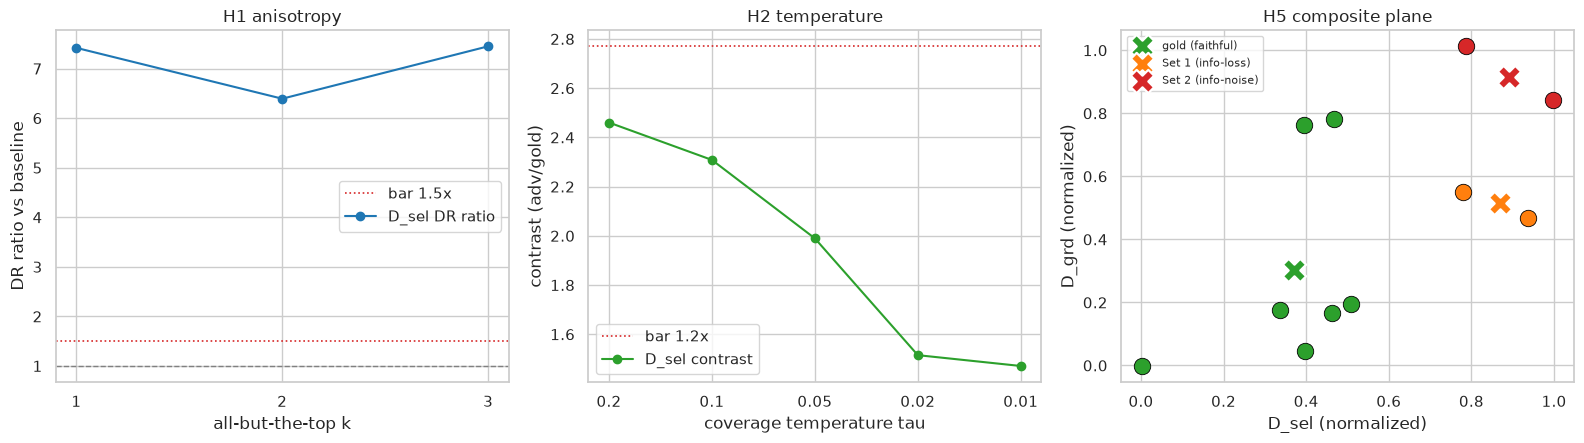

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

ax[0].axhline(1.0, color="gray", ls="--", lw=1)
ax[0].axhline(DR_BAR, color="#d62728", ls=":", lw=1.2, label=f"bar {DR_BAR}x")
ax[0].plot(K_ANISO, H1_RATIOS, marker="o", color="#1f77b4", label="D_sel DR ratio")
ax[0].set_xlabel("all-but-the-top k"); ax[0].set_ylabel("DR ratio vs baseline"); ax[0].set_title("H1 anisotropy"); ax[0].set_xticks(K_ANISO); ax[0].legend()

ax[1].axhline(CON0 * CONTRAST_BAR, color="#d62728", ls=":", lw=1.2, label=f"bar {CONTRAST_BAR}x")
ax[1].plot([str(t) for t in TAU_SWEEP], H2_CON, marker="o", color="#2ca02c", label="D_sel contrast")
ax[1].set_xlabel("coverage temperature tau"); ax[1].set_ylabel("contrast (adv/gold)"); ax[1].set_title("H2 temperature"); ax[1].legend()

nsel_b, ngrd_b = minmax(d_sel_star), minmax(d_grd_star)
rng = np.random.default_rng(SEED)
for l in labels:
    jx, jy = rng.normal(0, 0.012, 2)
    ax[2].scatter(nsel_b[l] + jx, ngrd_b[l] + jy, s=140, color=TIER_COLOR[TIER[l]], edgecolor="black", lw=0.6, zorder=3)
for tier in TIERS:
    pts = [(nsel_b[l], ngrd_b[l]) for l in labels if TIER[l] == tier]
    ax[2].scatter(np.mean([p[0] for p in pts]), np.mean([p[1] for p in pts]), marker="X", s=280,
                  color=TIER_COLOR[tier], edgecolor="white", lw=1.6, zorder=4, label=TIER_NAME[tier])
ax[2].set_xlabel("D_sel (normalized)"); ax[2].set_ylabel("D_grd (normalized)"); ax[2].set_title("H5 composite plane"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Results - verdicts and save

Assemble the per-hypothesis verdicts and measured numbers, save to `reports/`, print the batch summary.

In [14]:
def verdict_label(passed, killed):
    if not killed: return "Refuted (killed at gate)"
    return "Confirmed" if passed else "Refuted"

results = {
    "device": DEVICE,
    "baseline": {"d_sel_DR": DR0, "d_sel_violations": V0, "d_sel_contrast": CON0,
                 "d_grd_gold_intrusions": GI0, "symmetric_severity": severity_order(d_sym)},
    "E04-H1": {**H1, "killed": H1["kill_pass"], "verdict": verdict_label(H1_PASS, H1["kill_pass"])},
    "E04-H2": {**H2, "killed": H2["kill_pass"], "verdict": verdict_label(H2_PASS, H2["kill_pass"])},
    "E04-H3": {**H3, "killed": H3["kill_pass"], "verdict": verdict_label(H3_PASS, H3["kill_pass"])},
    "E04-H4": {**H4, "killed": H4["kill_pass"], "verdict": verdict_label(H4_PASS, H4["kill_pass"])},
    "E04-H5": {**H5, "killed": H5["kill_pass"], "verdict": verdict_label(H5_PASS, H5["kill_pass"])},
}
out = ROOT / "reports/E04-source-conditioned-performance-metrics.json"
out.write_text(json.dumps(results, indent=2, default=float))

vt = Table(title="E04 verdicts", title_style="bold cyan", box=None, padding=(0, 2))
for c in ["hypothesis", "target KPI", "key result", "verdict"]:
    vt.add_column(c, justify="left")
vt.add_row("H1 anisotropy", "dynamic range", f"DR ratio {H1['dr_ratio']}, viol {H1['viol']}, aniso {H1['aniso']:.2f}", results["E04-H1"]["verdict"])
vt.add_row("H2 temperature", "dynamic range", f"best tau {H2['best_tau']}, contrast {H2['con_ratio']}", results["E04-H2"]["verdict"])
vt.add_row("H3 distilled (replace)", "speed", f"Spearman {H3['spearman']:.2f}, cut {H3['speed_cut']:.1f}x, recall@3 {H3['recall3']:.2f}", results["E04-H3"]["verdict"])
vt.add_row("H4 cascade", "speed", f"Spearman {H4['spearman']:.2f}, cut {H4['e2e_cut']:.1f}x, recall@m {H4['recall_m']:.2f}", results["E04-H4"]["verdict"])
vt.add_row("H5 composite", "resolution + cost", f"DR {H5['dr_ratio']:.2f}x, lat {H5['latency_cut']:.2f}x, {H5['severity']}", results["E04-H5"]["verdict"])
console.print(vt)
print("saved", out)

                                                   E04 verdicts                                                    
  hypothesis                target KPI           key result                              verdict                   
  H1 anisotropy             dynamic range        DR ratio 7.450009294649075, viol 0,     Confirmed                 
                                                 aniso 0.74                                                        
  H2 temperature            dynamic range        best tau None, contrast None            Refuted                   
  H3 distilled (replace)    speed                Spearman 0.70, cut 2.6x, recall@3       Refuted (killed at gate)  
                                                 0.55                                                              
  H4 cascade                speed                Spearman 0.98, cut 2.3x, recall@m       Refuted (killed at gate)  
                                                 0.87                                                              
  H5 composite              resolution + cost    DR 7.45x, lat 1.00x, Set2>Set1          Refuted (killed at gate)

saved /home/lab/workspace/learning/projects/docdistance/reports/E04-source-conditioned-performance-metrics.json


## Conclusions

Batch E04 set out to make the source-conditioned distance faster and higher-resolution without regressing correctness. One lever landed.

- **H1 anisotropy - Confirmed**: all-but-the-top over the pooled {A,B,S} statements widens the conditioned `D_sel` dynamic range to 7.45x (0.0193 → 0.144 at k=3, already 7.42x at k=1) while holding 0 ordinality violations; the kill-gate confirmed the coverage cosines are anisotropic (mean off-diagonal 0.736). Like its symmetric ancestor E01-H2, the gain is resolution, not a sharper boundary - the gold/adversarial contrast slips slightly (2.31x → 2.04x) because the within-tier band spreads too. Promote as an optional resolution pre-pass (the `anisotropy=True` flag, k=1)
- **H2 temperature - Refuted**: the prediction inverts. Lowering the coverage temperature raises dynamic range (0.0193 → 0.049) but lowers the contrast (2.31x → 1.47x) and breaks ordinality (V 0 → 2); temperature trades contrast for range rather than buying both
- **H3 distilled replacement - Refuted (killed at gate)**: `bge-reranker-base` recalls only 0.55 of the v2-m3 top-3, gives Spearman 0.70 and only 2.6x, and adds a gold intrusion; the cross-encoder is load-bearing even against its own smaller sibling
- **H4 cross-encoder cascade - Refuted (killed at gate)**: the near-miss. A tiny MiniLM pre-filter clears fidelity (Spearman 0.976) and speed (2.28x, v2-m3 calls 70 → 15) - far better than the E03 bi-encoder (0.55) - but recall@15 of the v2-m3 top-3 is 0.87 (gate 0.95) and the dropped evidence adds one gold intrusion. The closest faithful speed-up; a larger m or a better-matched pre-filter is the open direction
- **H5 composite - Refuted (killed at gate)**: with no speed lever landed, the composite reduces to the H1 resolution gain on the baseline reranker - DR 7.45x, 0 violations, 0 gold intrusions, blend Set2>Set1 (vs symmetric Set1>Set2), every guardrail held, but no latency improvement

**Net**: the resolution KPI has a clean win (H1, optional pre-pass), the cost KPI does not - the ~109 s/pair reranker grounding cost stands, with the H4 cascade the most promising future lever. SOTA consideration: H1 joins the optional anisotropy resolution lever for the conditioned `D_sel`; the speed levers stay refuted.
